In [5]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

In [6]:
tf.__version__

'2.19.1'

In [3]:
# load data
# 28x28 pixel grayscale images of handwritten digits (0-9)
(x_train, y_train), (x_test, y_test) = mnist.load_data() # x = images, y = labels

# normalize pixel values to range [0, 1] for better training stability
x_train = x_train / 255.0
x_test = x_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 12s 1us/step 


In [10]:
# build model
model = Sequential([
    # Flatten 2D images into 1D vector (784 elements)
    Flatten(input_shape=(28, 28)),

    # First hidden layer with 128 neurons and ReLU activation
    Dense(128, activation="relu"),

    # Second hidden layer with 64 neurons and ReLU activation
    Dense(64, activation="relu"),

    # Output layer with 10 neurons (one per digit), using softmax for probabilities
    Dense(10, activation="softmax")
])

# compile model
model.compile(optimizer="adam",
             loss="sparse_categorical_crossentropy",
             metrics=["accuracy"])

In [11]:
# train model
history = model.fit(x_train, y_train, epochs=5, batch_size=32, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8611 - loss: 0.4756 - val_accuracy: 0.9546 - val_loss: 0.1450
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9623 - loss: 0.1231 - val_accuracy: 0.9672 - val_loss: 0.1105
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9751 - loss: 0.0784 - val_accuracy: 0.9657 - val_loss: 0.1110
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9818 - loss: 0.0588 - val_accuracy: 0.9722 - val_loss: 0.1023
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9863 - loss: 0.0418 - val_accuracy: 0.9704 - val_loss: 0.1142


In [12]:
# evaluate model
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9656 - loss: 0.1255   
Test Accuracy: 0.9710000157356262


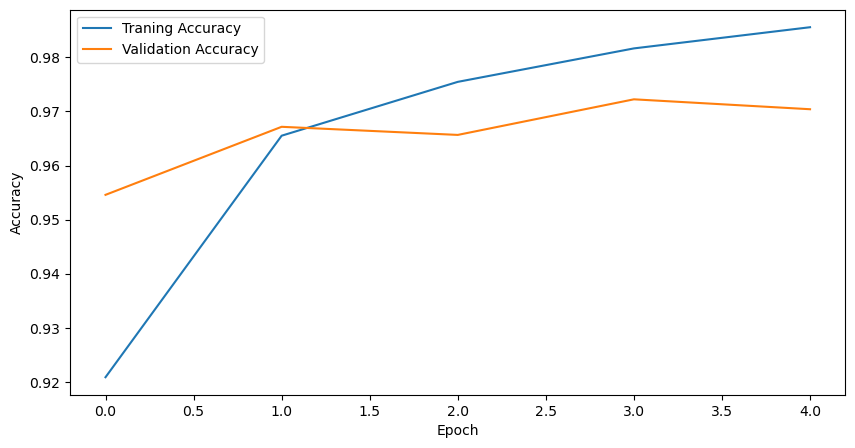

In [13]:
import matplotlib.pyplot as plt

# plot training history
plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Traning Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
w